In [2]:
import numpy as np
import os

import matplotlib.pyplot as plt

aac1
maximum_wire_lifetime = 7.4 ns


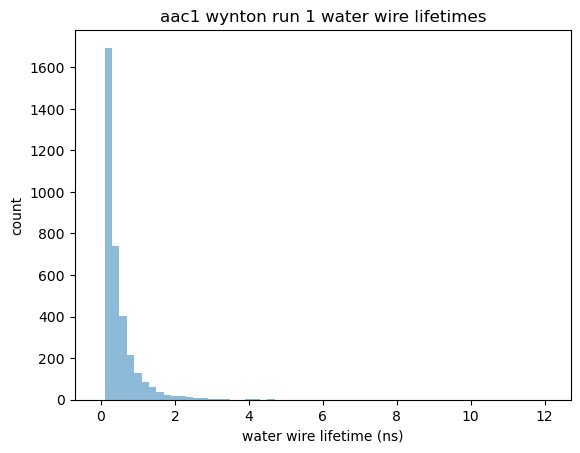

maximum_wire_lifetime = 1.0 ns


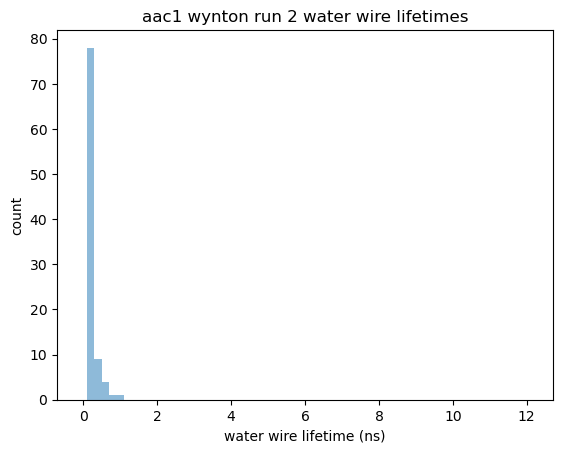

maximum_wire_lifetime = 0.7 ns


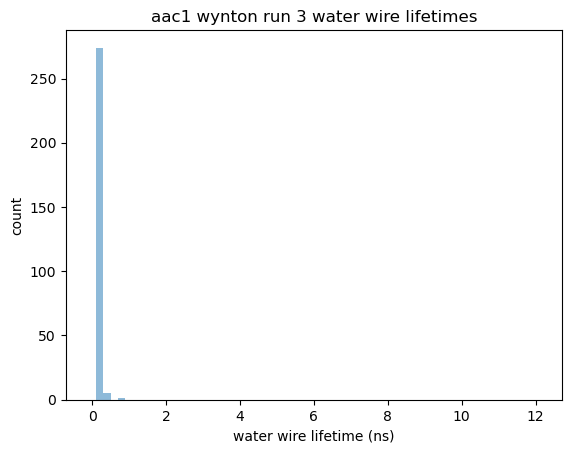

maximum_wire_lifetime = 0.0 ns


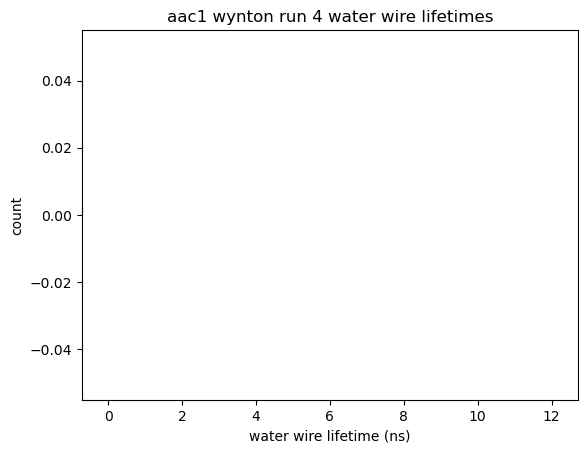

maximum_wire_lifetime = 0.4 ns


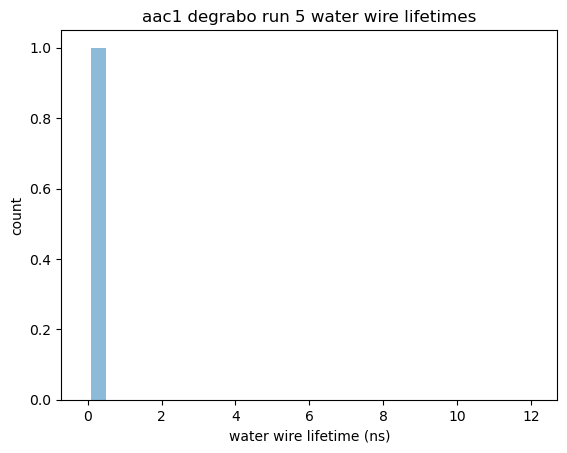

maximum_wire_lifetime = 11.600000000000001 ns


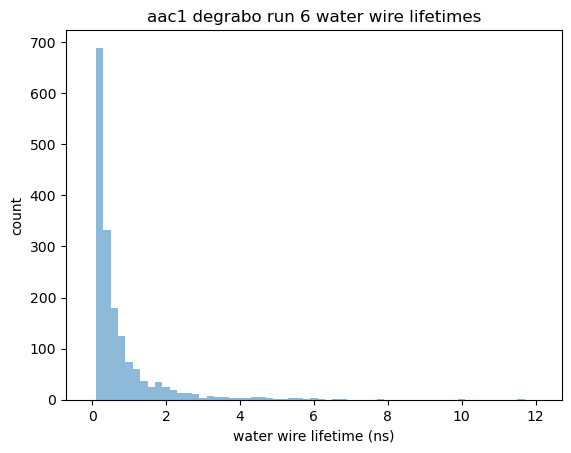

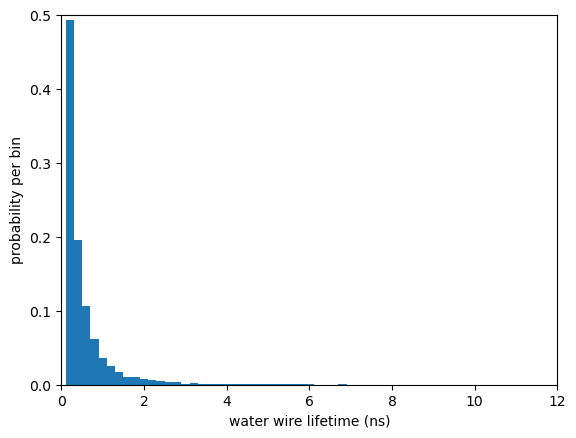

5549 total wire formation events
[0.24257987628397934, 0.0033110708625764093, 0.005709387055293613, 0.0, 0.0001197939543984347, 0.1719097212926026]
wire forms 0.0706+=0.0988 of the time
ucp1
maximum_wire_lifetime = 0.6000000000000001 ns


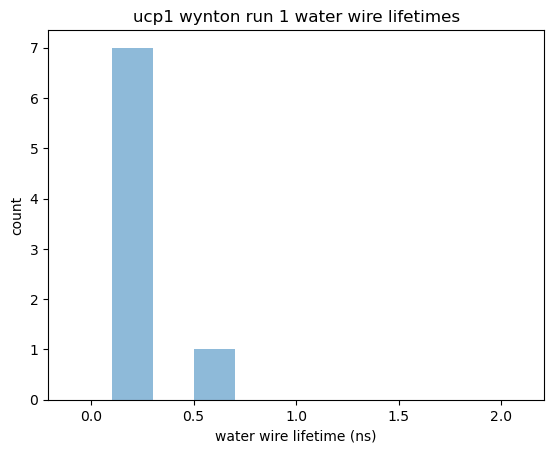

maximum_wire_lifetime = 0.6000000000000001 ns


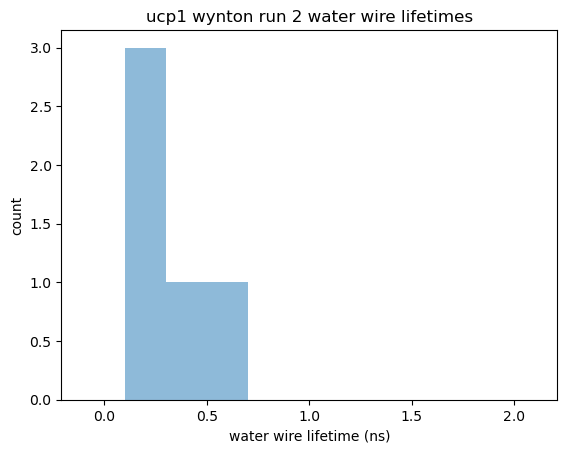

maximum_wire_lifetime = 0.1 ns


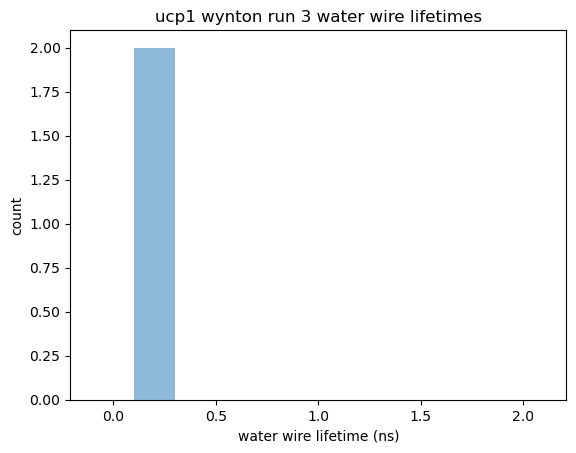

maximum_wire_lifetime = 1.6 ns


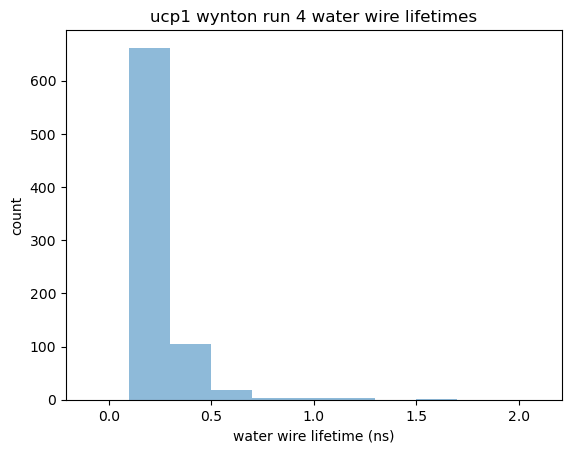

maximum_wire_lifetime = 0.4 ns


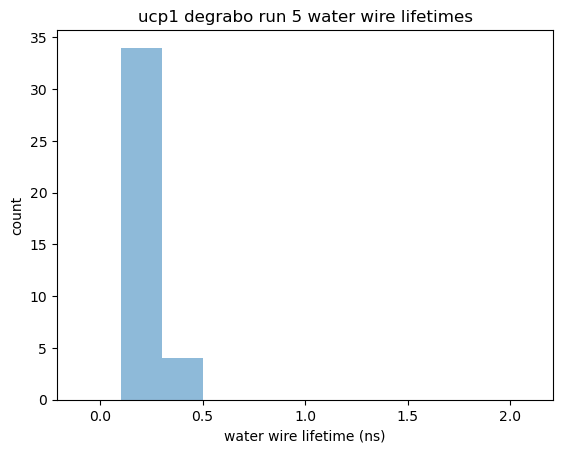

maximum_wire_lifetime = 0.4 ns


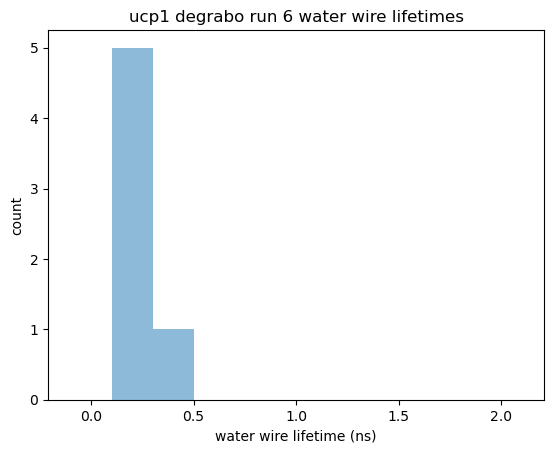

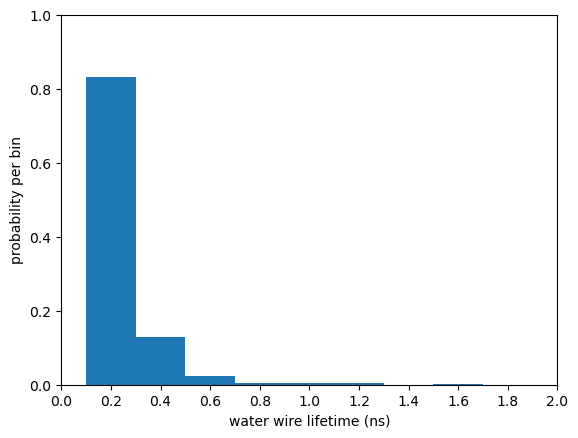

856 total wire formation events
[0.00026965807356272247, 0.0002205983730869985, 3.634645440337295e-05, 0.029497609141153822, 0.0013020833333333333, 0.0002366703857727288]
wire forms 0.0053+=0.0108 of the time


In [29]:
window = 500
threshold = 0.33
colors = ["cyan", "orange", "green", "red", "purple", "grey"]

freqplot = False
multiplot = True

def compile_wire_data():

    #inputpath = "/media/X01Raid01/Data_Backup/home/jborowsky/long-sims/long-aac1-ucp1-processing/water_wires"
    inputpath = "/home/jonathan/Documents/grabelab/aac1-ucp1/long-aac1-ucp1/water_wires"

    servers = ["wynton", "degrabo"]
    proteins = ["aac1", "ucp1"]

    #loop over servers, proteins, and parallel runs
    for protein in proteins:
        print(protein)
        wire_fractions = []
        legend = []
        ci = 0

        run_lengths_all = []

        if protein == "aac1":
            rmax = 12
        elif protein == "ucp1":
            rmax = 2

        bin_density = 5

        #pml_out_lines = ["delete all\n", f"load /home/jonathan/Documents/grabelab/aac1-ucp1/long-aac1-ucp1/long-aac1-ucp1-processing/wynton/{protein}/input/seg_0035.gro\n"] 
        for server in servers:
            #toppath = f"{inputpath}/{server}/{protein}/input/seg_0035.gro"
            for run in range(1,5):
                if server == "degrabo" and run > 2:
                    continue

                #segments are named differently on different servers
                if server == "wynton":
                    segs = ["001"]+[str(i) for i in range(100, 1000, 100)]
                elif server == "degrabo":
                    segs = [str(i).zfill(3) for i in range(1,20)]
                else:
                    segs = [] #ensure variable is defined

                #step is in microseconds
                if server == "wynton" and (run == 3 or run == 4):
                    step = 1/10000
                else:
                    step = 1/5000

                dists = []
 
                for si, seg in enumerate(segs):

                    folder = f"{inputpath}/{server}/{protein}/run0{run}/"
                    files = os.listdir(folder)

                    fnquery = f"{protein}-{server}-run0{run}-initseg{seg}"
                    files = [f for f in files if f[0:len(fnquery)] == fnquery and len(f.split("-")) == 8]
                    if len(files) == 0:
                        continue

                    for fi, f in enumerate(files):
                        dists.append(np.load(f"{folder}{f}"))

                dists = np.concatenate(dists)
                bin_dists = np.where(dists < threshold, 1, 0)

                run_lengths = []
                maxrun = 0
                run_init = 0

                for bd in range(len(bin_dists)-1):
                    if bin_dists[bd] == 0 and bin_dists[bd+1] == 1:
                        run_init = bd
                    elif bin_dists[bd] == 1 and bin_dists[bd+1] == 0:
                        run_lengths.append((bd - run_init)*step*1000) #in ns
                        if bd-run_init > maxrun:
                            maxrun = bd-run_init

                print(f"maximum_wire_lifetime = {maxrun*step*1000} ns")


                plt.hist(run_lengths, bins = rmax*bin_density+1, range = [-1/(2*bin_density), rmax+1/(2*bin_density)], alpha = 0.5, density=False)
                plt.title(f"{protein} {server} run {ci+1} water wire lifetimes")
                plt.ylabel("count")
                plt.xlabel(f"water wire lifetime (ns)")
                plt.show()

                run_lengths_all += run_lengths

                wire_fractions.append(np.mean(bin_dists))

                ci += 1


        #make bin heights add to 1
        weights = np.ones(len(run_lengths_all)) / len(run_lengths_all)
        plt.hist(run_lengths_all, weights=weights, bins = rmax*bin_density+1, range = [-1/(2*bin_density), rmax+1/(2*bin_density)])
        #plt.title(f"{protein} overall water wire lifetimes")

        plt.ylabel("probability per bin")
        plt.xlabel(f"water wire lifetime (ns)")
        if protein == "ucp1":
            plt.xticks(np.arange(0, rmax+0.1, 0.2))

        plt.xlim(0,rmax)

        if protein == "aac1":
            plt.ylim(0, 0.5)
        elif protein == "ucp1":
            plt.ylim(0, 1)

        plt.savefig(f"{inputpath}/water_wire_lifetime_distribution_{protein}.svg", bbox_inches='tight', format ='svg')


        plt.show()

        print(f"{len(run_lengths_all)} total wire formation events")

        print(wire_fractions)
        print(f"wire forms {np.round(np.mean(wire_fractions), 4)}+={np.round(np.std(wire_fractions), 4)} of the time")


compile_wire_data()
